<a href="https://colab.research.google.com/github/Hackathon-05-06-2026/Hackathon_Files/blob/main/KNN_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Loaded Training Set from: /content/drive/MyDrive/Hackathon_05 06/super_dataset_C_train.csv
re-trained successfully and active in memory.

🔮 Step 4: Computing SHAP values using KernelExplainer (Optimized Slice)...


  0%|          | 0/50 [00:00<?, ?it/s]

<Figure size 1100x700 with 0 Axes>

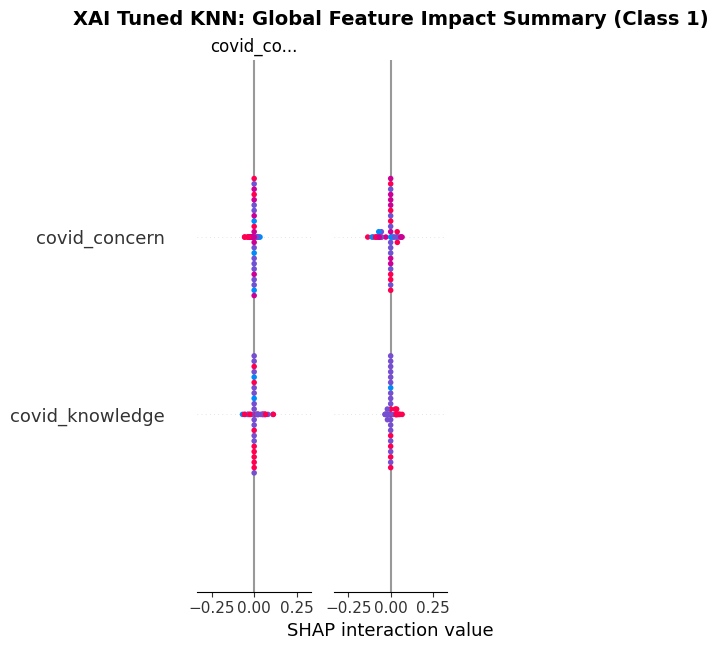

Tuned KNN SHAP plot exported directly to Drive folder:
   /content/drive/MyDrive/Hackathon_05 06/tuned_knn_shap_xai.png


In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
!pip install -q shap
import shap
drive.mount('/content/drive')

#load data
search_train = '/content/drive/MyDrive/Dataset*C/super_dataset_C_train.csv'
train_files = glob.glob(search_train) or glob.glob('/content/drive/MyDrive/Hackathon_05*06/super_dataset_C_train.csv')

if len(train_files) > 0:
    file_path = train_files[0]
    df_train = pd.read_csv(file_path)
    print(f"Loaded Training Set from: {file_path}")
else:
    raise FileNotFoundError("Could not find 'super_dataset_C_train.csv'.")

# Isolate features and target labels
y_train_full = df_train['covid_vaccine']
X_train_full = df_train.drop(columns=['covid_vaccine'])

#HP tuned KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)
tuned_knn = KNeighborsClassifier(metric='manhattan', n_neighbors=9, weights='distance')
tuned_knn.fit(X_train, y_train)
print("re-trained successfully and active in memory.")

#XAI via SHAP kernel Explainer
print("\n🔮 Step 4: Computing SHAP values using KernelExplainer (Optimized Slice)...")

X_train_summary = shap.kmeans(X_train, 50)
X_val_sample = X_val.sample(50, random_state=42)
explainer = shap.KernelExplainer(tuned_knn.predict_proba, X_train_summary)
shap_values = explainer.shap_values(X_val_sample)
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
elif hasattr(shap_values, 'values') and len(shap_values.shape) == 3:
    shap_values_to_plot = shap_values[:, :, 1]
else:
    shap_values_to_plot = shap_values

#reshape and export plot
plt.figure(figsize=(11, 7))
shap.summary_plot(shap_values_to_plot, X_val_sample, show=False)

plt.title("XAI Tuned KNN: Global Feature Impact Summary (Class 1)", fontweight='bold', fontsize=14, pad=25)
plt.tight_layout()

#save image to shared path
knn_plot_path = file_path.replace('super_dataset_C_train.csv', 'tuned_knn_shap_xai.png')
plt.savefig(knn_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Tuned KNN SHAP plot exported directly to Drive folder:\n   {knn_plot_path}")